In [1]:
from keras.layers import Dense,Dropout, BatchNormalization,Flatten
from keras.models import load_model,save_model
from keras.models import Model
from keras.applications.vgg19 import VGG19
from keras.applications.vgg16 import preprocess_input
from keras.preprocessing import image
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
import numpy as np
import pandas as pd
from glob import glob
import matplotlib.pyplot as plt
from PIL import ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True

In [ ]:
train_path = '/datasets/train'
valid_path = '/datasets/test'

In [3]:
IMAGE_SIZE = [224, 224]
vgg = VGG19(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

In [4]:
# don't train existing weights
for layer in vgg.layers:
    layer.trainable = False

In [6]:
x = Flatten()(vgg.output)
# x = Dense(1000, activation='relu')(x)
prediction = Dense(len(folders), activation='softmax')(x)

In [7]:
# create a model object
model = Model(inputs=vgg.input, outputs=prediction)

In [8]:
# view the structure of the model
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0     

In [9]:
# tell the model what cost and optimization method to use
model.compile(loss='categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

In [ ]:
from keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(rescale = 1./255,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True)

val_datagen = ImageDataGenerator(rescale = 1./255)

training_set = train_datagen.flow_from_directory('/datasets/train',
                                                 target_size = (224, 224),
                                                 batch_size = 32,
                                                 class_mode = 'categorical')

val_set = val_datagen.flow_from_directory('/datasets/test',
                                            target_size = (224, 224),
                                            batch_size = 32,
                                            class_mode = 'categorical')

# fit the model
history = model.fit_generator(training_set,
                              validation_data=val_set,
                              epochs=20,
                              steps_per_epoch=len(training_set),
                              validation_steps=len(val_set))


Found 1034 images belonging to 3 classes.
Found 1034 images belonging to 3 classes.


C:\Users\vishw\AppData\Local\Temp\ipykernel_8668\1514554645.py:20: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(training_set,


Epoch 1/20
33/33 [==============================] - 302s 9s/step - loss: 0.9003 - accuracy: 0.6547 - val_loss: 0.3492 - val_accuracy: 0.8772
Epoch 2/20
33/33 [==============================] - 294s 9s/step - loss: 0.3363 - accuracy: 0.8849 - val_loss: 0.2398 - val_accuracy: 0.9323
Epoch 3/20
33/33 [==============================] - 285s 9s/step - loss: 0.2673 - accuracy: 0.8985 - val_loss: 0.2079 - val_accuracy: 0.9333
Epoch 4/20
33/33 [==============================] - 286s 9s/step - loss: 0.2242 - accuracy: 0.9120 - val_loss: 0.1701 - val_accuracy: 0.9516
Epoch 5/20
33/33 [==============================] - 289s 9s/step - loss: 0.2046 - accuracy: 0.9313 - val_loss: 0.1601 - val_accuracy: 0.9516
Epoch 6/20
33/33 [==============================] - 304s 9s/step - loss: 0.1793 - accuracy: 0.9420 - val_loss: 0.1299 - val_accuracy: 0.9632
Epoch 7/20
33/33 [==============================] - 315s 10s/step - loss: 0.1616 - accuracy: 0.9468 - val_loss: 0.1356 - val_accuracy: 0.9545
Epoch 8/20
3

        loss  accuracy  val_loss  val_accuracy
0   0.900334  0.654739  0.349203      0.877176
1   0.336257  0.884913  0.239842      0.932302
2   0.267259  0.898453  0.207936      0.933269
3   0.224155  0.911992  0.170058      0.951644
4   0.204552  0.931335  0.160135      0.951644
5   0.179303  0.941973  0.129892      0.963250
6   0.161559  0.946809  0.135604      0.954545
7   0.175442  0.938104  0.096129      0.978723
8   0.134196  0.960348  0.087592      0.979691
9   0.124488  0.961315  0.084971      0.985493
10  0.113344  0.970986  0.085375      0.977756
11  0.111690  0.964217  0.075400      0.978723
12  0.114167  0.967118  0.139542      0.937137
13  0.112088  0.965184  0.079777      0.984526
14  0.093619  0.970986  0.055172      0.994197
15  0.083969  0.969052  0.053227      0.990329
16  0.086511  0.977756  0.046305      0.994197
17  0.087648  0.970019  0.067281      0.982592
18  0.069373  0.979691  0.039814      0.995164
19  0.064945  0.981625  0.044102      0.991296


<AxesSubplot:>

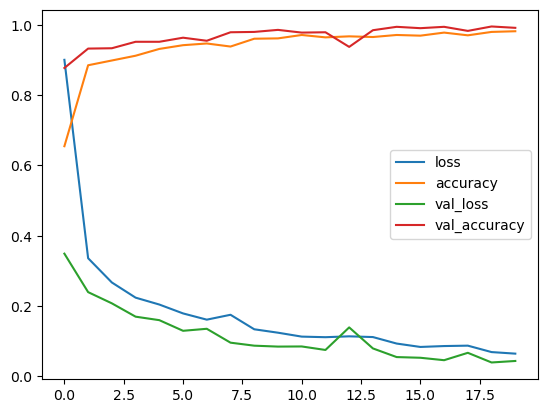

In [11]:
from keras.models import load_model

model.save('model.h5')


print(pd.DataFrame(history.history))

pd.DataFrame(history.history).plot()

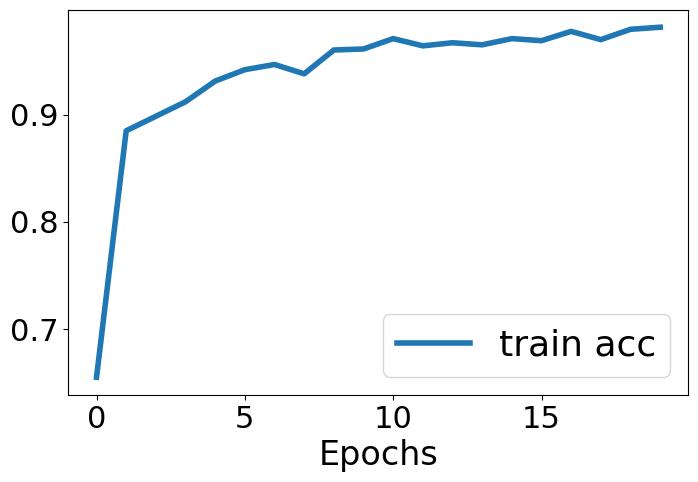

In [12]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots( figsize = (8,5))
ax.plot(history.history['accuracy'], label= 'train acc', linewidth = 4)
ax.legend(fontsize = 26)
ax.tick_params(labelsize=22)
ax.set_xlabel('Epochs', fontsize = 24)


plt.show()
